In [1]:
# ==============================================================================
# BENCHMARK 2: Swin-Base on HAM10000 (Shifted-Window ViT Baseline)
# Course: CSE463 Computer Vision Term Project
# Output: best_swin_base_ham10000.pth & swin_base_metrics.csv
# ==============================================================================

import os
import glob
import copy
import zipfile
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.cuda.amp import autocast, GradScaler
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, 
    recall_score, roc_auc_score, classification_report
)
from IPython.display import FileLink

# 1. Config & Environment Setup
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = "/kaggle/working/swin_run_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_NAME = "Swin-Base"
TIMM_TAG = "swin_base_patch4_window7_224.ms_in22k_ft_in1k"
NUM_CLASSES = 7
BATCH_SIZE = 32
NUM_WORKERS = 4
EPOCHS = 10
LR = 1e-4
WEIGHT_DECAY = 1e-2
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"[+] Active GPU: {DEVICE} | Model: {MODEL_NAME}")

# 2. HAM10000 Lesion-Level Deduplicated Split
def load_ham10000_splits(base_dir="/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"):
    csv_path = os.path.join(base_dir, "HAM10000_metadata.csv")
    df = pd.read_csv(csv_path)
    
    all_images = glob.glob(os.path.join(base_dir, "**", "*.jpg"), recursive=True)
    image_dict = {os.path.splitext(os.path.basename(p))[0]: p for p in all_images}
    df['path'] = df['image_id'].map(image_dict)
    df = df.dropna(subset=['path']).reset_index(drop=True)
    
    label_mapping = {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
    df['label'] = df['dx'].map(label_mapping)
    
    unique_lesions = df.drop_duplicates(subset=['lesion_id']).reset_index(drop=True)
    train_val, test_lesions = train_test_split(
        unique_lesions, test_size=0.15, stratify=unique_lesions['label'], random_state=SEED
    )
    train_lesions, val_lesions = train_test_split(
        train_val, test_size=0.1765, stratify=train_val['label'], random_state=SEED
    )
    
    train_df = df[df['lesion_id'].isin(train_lesions['lesion_id'])].reset_index(drop=True)
    val_df = df[df['lesion_id'].isin(val_lesions['lesion_id'])].reset_index(drop=True)
    test_df = df[df['lesion_id'].isin(test_lesions['lesion_id'])].reset_index(drop=True)
    
    print(f"[+] Splits -> Train: {len(train_df)} | Val: {len(val_df)} | Blind Test: {len(test_df)}")
    return train_df, val_df, test_df

# 3. Standard Dermatology Dataset Loader
class DermatologyDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['path']
        label = self.df.iloc[idx]['label']
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(norm_mean, norm_std)
])

eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(norm_mean, norm_std)
])

train_df, val_df, test_df = load_ham10000_splits()
train_loader = DataLoader(DermatologyDataset(train_df, train_transforms), batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(DermatologyDataset(val_df, eval_transforms), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(DermatologyDataset(test_df, eval_transforms), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# 4. Model Training Routine
model = timm.create_model(TIMM_TAG, pretrained=True, num_classes=NUM_CLASSES).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()
scaler = GradScaler()

best_val_acc = 0.0
weight_path = os.path.join(OUTPUT_DIR, "best_swin_base_ham10000.pth")

print("\n--- Starting Swin-Base Fine-Tuning ---")
for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss, train_correct, total_train = 0.0, 0, 0
    for images, targets in train_loader:
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * targets.size(0)
        train_correct += (outputs.argmax(1) == targets).sum().item()
        total_train += targets.size(0)
        
    scheduler.step()
    
    # Validation
    model.eval()
    val_correct, total_val = 0, 0
    with torch.no_grad():
        for images, targets in val_loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            with autocast():
                outputs = model(images)
            val_correct += (outputs.argmax(1) == targets).sum().item()
            total_val += targets.size(0)
            
    val_acc = val_correct / total_val
    print(f"Epoch [{epoch:02d}/{EPOCHS}] | Train Acc: {(train_correct/total_train)*100:.2f}% | Val Acc: {val_acc*100:.2f}%")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), weight_path)

# 5. Final Blind Test Evaluation
print("\n--- Evaluating Best Model on 15% Blind Stratified Test Split ---")
model.load_state_dict(torch.load(weight_path))
model.eval()

y_true, y_pred, y_probs = [], [], []
with torch.no_grad():
    for images, targets in test_loader:
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        with autocast():
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
        y_true.extend(targets.cpu().numpy())
        y_pred.extend(outputs.argmax(1).cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

y_true, y_pred, y_probs = np.array(y_true), np.array(y_pred), np.array(y_probs)
target_names = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']

acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro')
macro_prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
macro_rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
macro_auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')

print(f"\n>>> SWIN-BASE TEST METRICS:")
print(f"    Accuracy       : {acc*100:.2f}%")
print(f"    Macro F1       : {macro_f1:.4f}")
print(f"    Macro ROC-AUC  : {macro_auc:.4f}")
print("\n" + classification_report(y_true, y_pred, target_names=target_names, digits=4))

# 6. Save Metrics and Export Bundle
metrics_df = pd.DataFrame([{
    "Model": "Swin-Base",
    "Dataset": "HAM10000",
    "Test Accuracy": f"{acc*100:.2f}%",
    "Macro F1": round(macro_f1, 4),
    "Macro Precision": round(macro_prec, 4),
    "Macro Recall": round(macro_rec, 4),
    "Macro ROC-AUC": round(macro_auc, 4)
}])
metrics_csv = os.path.join(OUTPUT_DIR, "swin_base_metrics.csv")
metrics_df.to_csv(metrics_csv, index=False)

zip_file = "/kaggle/working/swin_ham10000_results.zip"
with zipfile.ZipFile(zip_file, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for f in os.listdir(OUTPUT_DIR):
        zipf.write(os.path.join(OUTPUT_DIR, f), arcname=f)

print("[+] Bundle ready for direct download to Google Drive / Local PC:")
FileLink(r'swin_ham10000_results.zip')

[+] Active GPU: cuda | Model: Swin-Base
[+] Splits -> Train: 7018 | Val: 1507 | Blind Test: 1490


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]


--- Starting Swin-Base Fine-Tuning ---


/tmp/ipykernel_58/4097394925.py:120: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_58/4097394925.py:132: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_58/4097394925.py:151: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [01/10] | Train Acc: 76.65% | Val Acc: 78.57%
Epoch [02/10] | Train Acc: 85.67% | Val Acc: 85.20%
Epoch [03/10] | Train Acc: 89.70% | Val Acc: 83.88%
Epoch [04/10] | Train Acc: 93.49% | Val Acc: 83.15%
Epoch [05/10] | Train Acc: 95.64% | Val Acc: 85.67%
Epoch [06/10] | Train Acc: 98.01% | Val Acc: 87.39%
Epoch [07/10] | Train Acc: 98.89% | Val Acc: 87.13%
Epoch [08/10] | Train Acc: 99.49% | Val Acc: 87.46%
Epoch [09/10] | Train Acc: 99.84% | Val Acc: 87.19%
Epoch [10/10] | Train Acc: 99.93% | Val Acc: 86.99%

--- Evaluating Best Model on 15% Blind Stratified Test Split ---


/tmp/ipykernel_58/4097394925.py:171: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



>>> SWIN-BASE TEST METRICS:
    Accuracy       : 84.30%
    Macro F1       : 0.7073
    Macro ROC-AUC  : 0.9679

              precision    recall  f1-score   support

       AKIEC     0.5439    0.6889    0.6078        45
         BCC     0.7722    0.8133    0.7922        75
         BKL     0.7018    0.7317    0.7164       164
          DF     0.7333    0.5238    0.6111        21
         MEL     0.6371    0.4969    0.5583       159
          NV     0.9159    0.9361    0.9259      1001
        VASC     0.8095    0.6800    0.7391        25

    accuracy                         0.8430      1490
   macro avg     0.7305    0.6958    0.7073      1490
weighted avg     0.8398    0.8430    0.8397      1490

[+] Bundle ready for direct download to Google Drive / Local PC:


/kaggle/working/swin_ham10000_results.zip

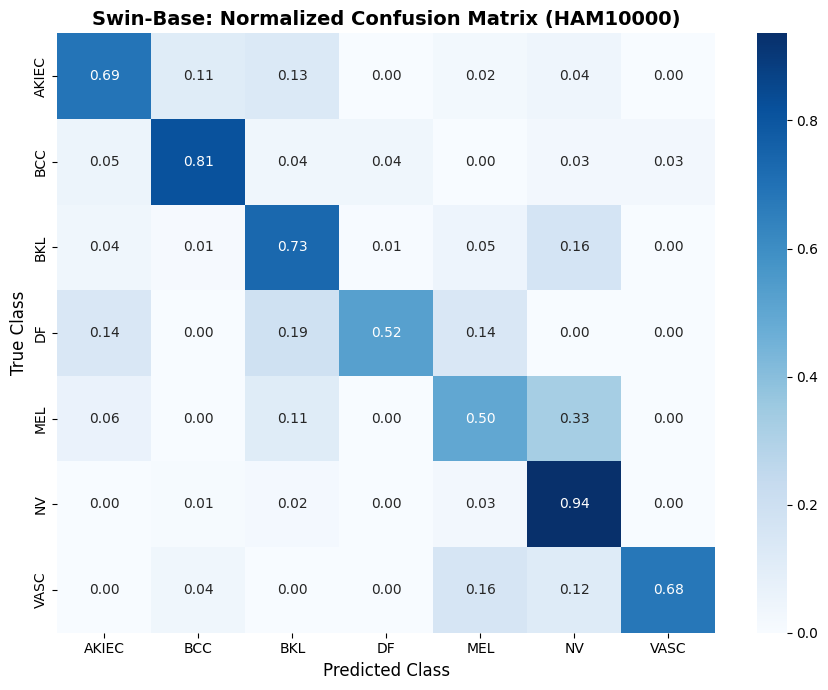

[+] Confusion matrix saved at: /kaggle/working/swin_run_outputs/swin_confusion_matrix.png


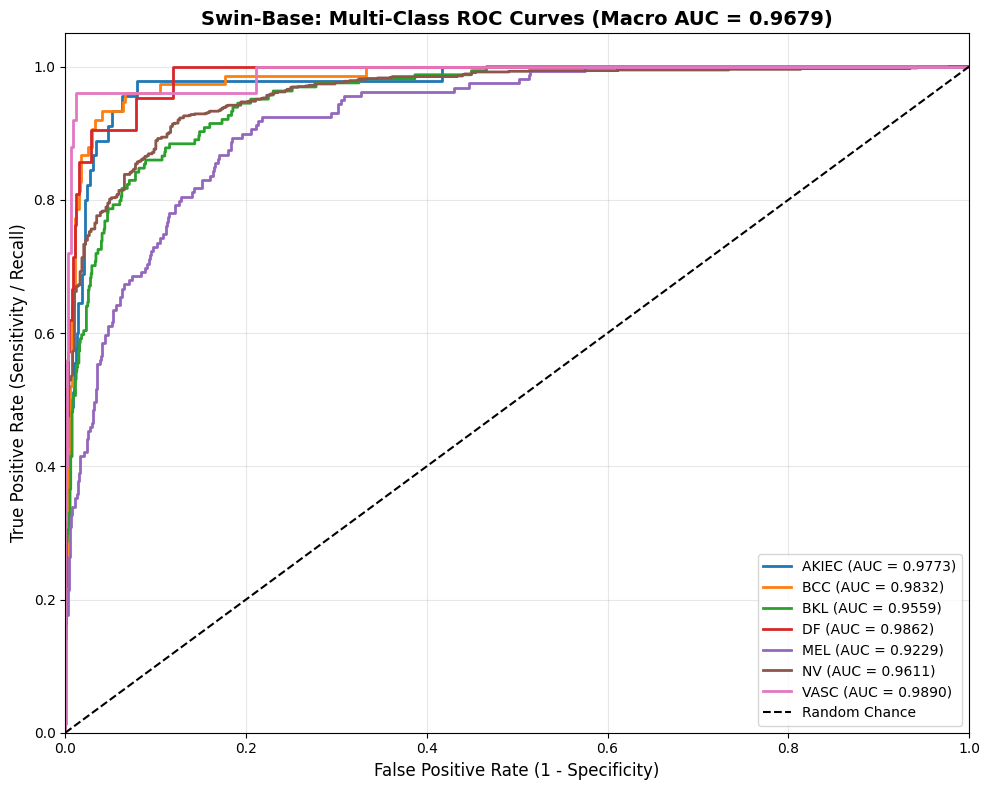

[+] ROC-AUC curves saved at: /kaggle/working/swin_run_outputs/swin_roc_curves.png


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Target class labels for HAM10000
target_names = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']

# -------------------------------------------------------------------------
# 1. GENERATE & SAVE SWIN-BASE CONFUSION MATRIX
# -------------------------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_normalized, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    xticklabels=target_names, 
    yticklabels=target_names,
    cbar=True
)
plt.title("Swin-Base: Normalized Confusion Matrix (HAM10000)", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("True Class", fontsize=12)
plt.tight_layout()

cm_path = os.path.join(OUTPUT_DIR, "swin_confusion_matrix.png")
plt.savefig(cm_path, dpi=300)
plt.show()
print(f"[+] Confusion matrix saved at: {cm_path}")

# -------------------------------------------------------------------------
# 2. GENERATE & SAVE SWIN-BASE MULTI-CLASS ROC-AUC CURVES
# -------------------------------------------------------------------------
# Binarize labels for One-vs-Rest ROC calculation
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(
        fpr[i], tpr[i], color=color, lw=2,
        label=f"{target_names[i]} (AUC = {roc_auc[i]:.4f})"
    )

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label="Random Chance")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=12)
plt.title(f"Swin-Base: Multi-Class ROC Curves (Macro AUC = {macro_auc:.4f})", fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()

roc_path = os.path.join(OUTPUT_DIR, "swin_roc_curves.png")
plt.savefig(roc_path, dpi=300)
plt.show()
print(f"[+] ROC-AUC curves saved at: {roc_path}")